<a href="https://colab.research.google.com/github/sankarramamurthy/SMU_DS_Capstone_Project/blob/main/SMU_DS_Capstone_SankarRamamurthy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problem Statement

This case study is about risk analytics in banking and financial services. It is important to minimise the risk of losing money while lending to customers.

The loan providing companies find it hard to give loans to the people due to their insufficient or non-existent credit history. Because of that, some consumers use it as their advantage by becoming a defaulter. Suppose you work for a consumer finance company which specialises in lending various types of loans to urban customers. You have to use EDA to analyse the patterns present in the data. This will ensure that the applicants capable of repaying the loan are not rejected.

When the company receives a loan application, the company has to decide for loan approval based on the applicant’s profile. Two types of risks are associated with the bank’s decision:

If the applicant is likely to repay the loan, then not approving the loan results in a loss of business to the company.
If the applicant is not likely to repay the loan, that is, he/she is likely to default, then approving the loan may lead to a financial loss for the company.

Based on the different attributes given in the dataset, predict whether the person is eligible for a loan or not

# Data Source

The data source for this business problem is available in the following Github Repository:
https://raw.githubusercontent.com/sankarramamurthy/SMU_DS_Capstone_Project/refs/heads/main/SMU_DS_Capstone_DataSet_CSV.csv

# Import the Dataset and analyse the basic stats of the dataset

In [85]:
# Import the essential libraries
import pandas as pd
import numpy as np # For mathematical calculations
import matplotlib.pyplot as plt # For plotting graphs
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")
import seaborn as sns # For data visualization

In [86]:
dataset_url = "https://raw.githubusercontent.com/sankarramamurthy/SMU_DS_Capstone_Project/refs/heads/main/SMU_DS_Capstone_DataSet_CSV.csv"
df = pd.read_csv(dataset_url)
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [87]:
df.shape

(614, 13)

In [88]:
df.dtypes

,0
Loan_ID,object
Gender,object
Married,object
Dependents,object
Education,object
Self_Employed,object
ApplicantIncome,int64
CoapplicantIncome,float64
LoanAmount,float64
Loan_Amount_Term,float64


Following are the initial observations regarding the dataset:

*   The dataset has 614 rows and 13 columns
*   There are 12 Independent variables and 1 Target variable i.e. Loan_Status
*   6 of the Independent variables are categorical variables and of are Object datatype


In [89]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


# Analyse the Target variable using Visualisation Techniques

The Target Variable *Loan Status* is a Categorical variable. So let's first look at the % distribution of each categories in that variable

In [90]:
df['Loan_Status'].value_counts()

,count
Loan_Status,
Y,422
N,192


<Axes: xlabel='Loan_Status'>

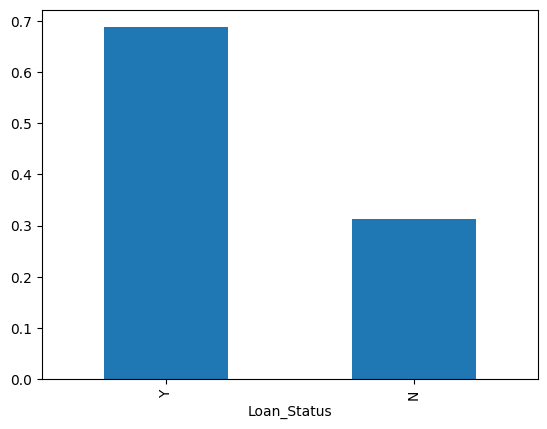

In [91]:
df['Loan_Status'].value_counts(normalize=True).plot(kind='bar')

From the above chart, it can be observed that 69% of people out of 614 got approval for their loan application.

Now, we shall analyse the Categorical variables: Gender, Marital status, Education and credit history. This analysis would be done using visualisation techniques.

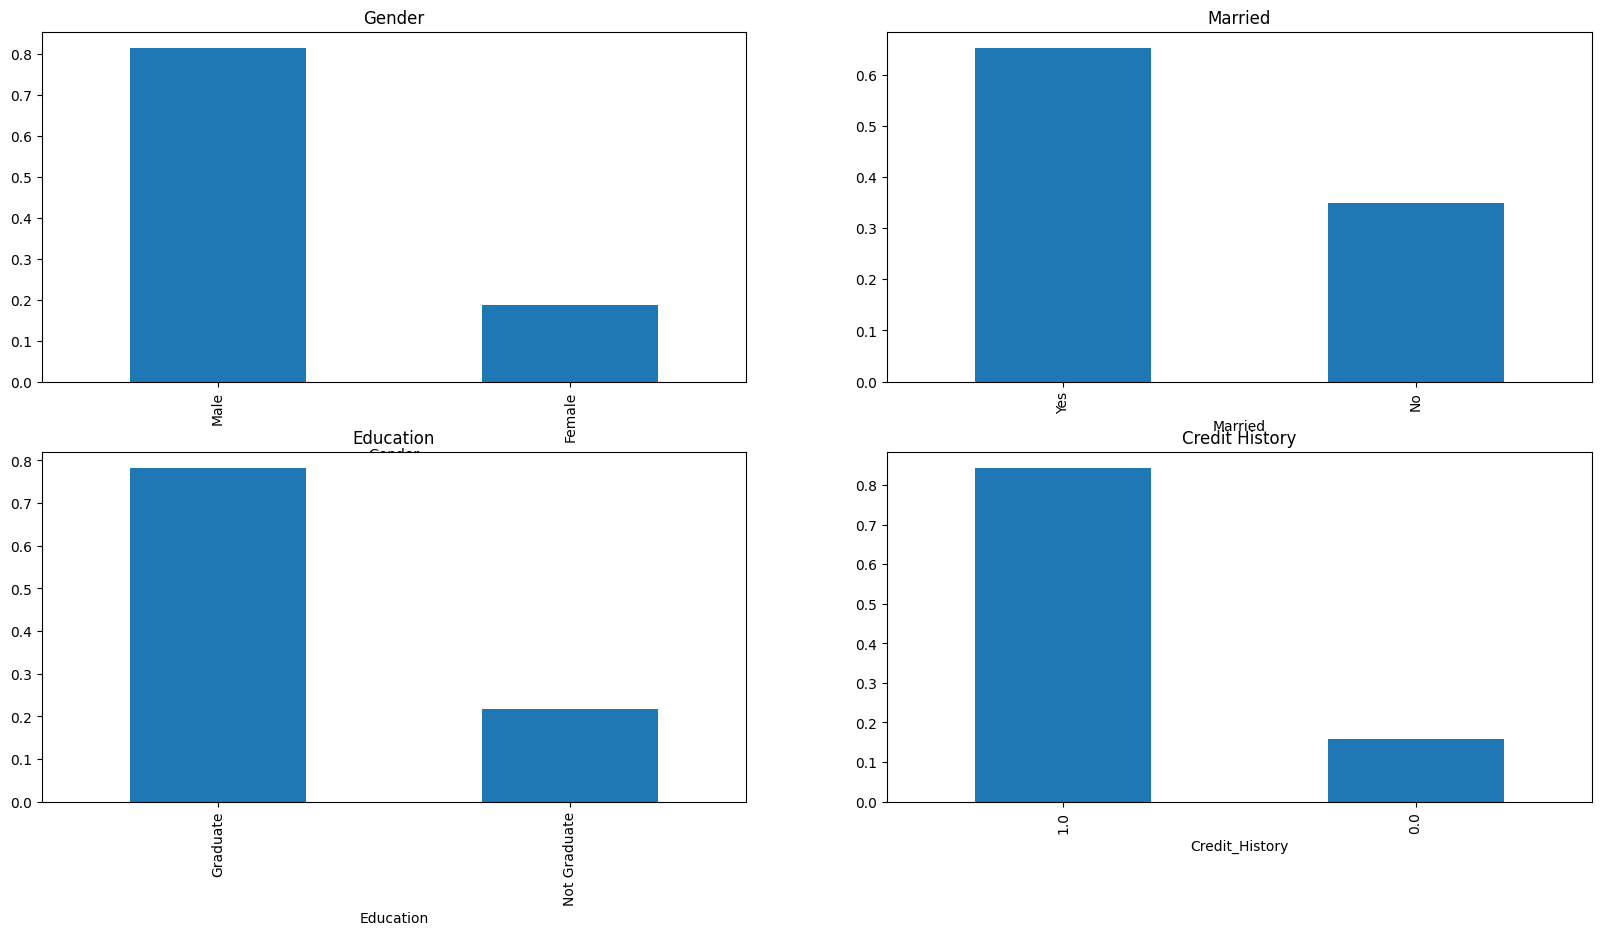

In [92]:
plt.figure(1)
plt.subplot(221)
df['Gender'].value_counts(normalize=True).plot.bar(figsize=(20,10), title= 'Gender')
plt.subplot(222)
df['Married'].value_counts(normalize=True).plot.bar(title= 'Married')
plt.subplot(223)
df['Education'].value_counts(normalize=True).plot.bar(title= 'Education')
plt.subplot(224)
df['Credit_History'].value_counts(normalize=True).plot.bar(title= 'Credit History')
plt.show()

It can be inferred from the above bar plots that:

*   80% of applicants in the dataset are male.
*   Around 65% of the applicants in the dataset are married.
*   Around 78% of applicants in the dataset are Graduates.
*   About 85% of applicants have repaid their debts.



Now, we shall analyse the Categorical variables: Dependents, Education, Propert_Area. This analysis would be done using visualisation techniques.

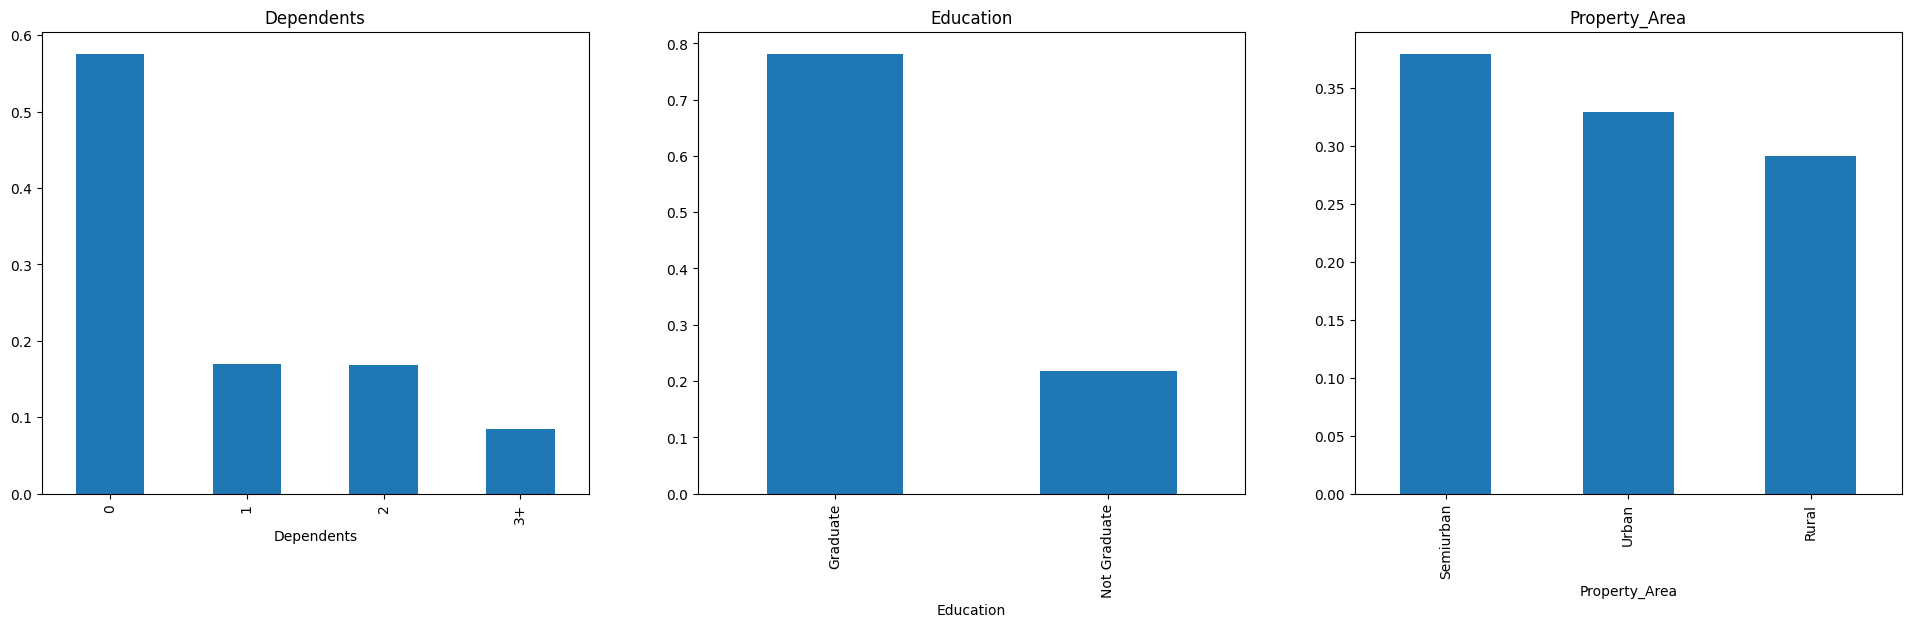

In [93]:
plt.figure(1)
plt.subplot(131)
df['Dependents'].value_counts(normalize=True).plot.bar(figsize=(24,6),title='Dependents')
plt.subplot(132)
df['Education'].value_counts(normalize=True).plot.bar(title= 'Education')
plt.subplot(133)
df['Property_Area'].value_counts(normalize=True).plot.bar(title= 'Property_Area')
plt.show()

Following inferences can be made from the above bar plots:

*   Most of the applicants don’t have dependents.
*   About 80% of the applicants are graduates.
*   Most of the applicants are from semi-urban areas.

# Analyse the dataset and compare Loan Status based on the other dependent variables

## Loan Status Vs. Gender

<Axes: xlabel='Gender'>

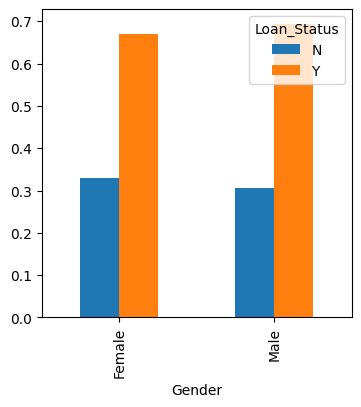

In [94]:
Gender = pd.crosstab(df['Gender'], df['Loan_Status'])
Gender.div(Gender.sum(1).astype(float), axis=0).plot(kind="bar", figsize=(4,4))

It can be inferred that the proportion loan approvals is more or less same for Female as well as Male applicants.

## Loan Status Vs. Marital Status

<Axes: xlabel='Married'>

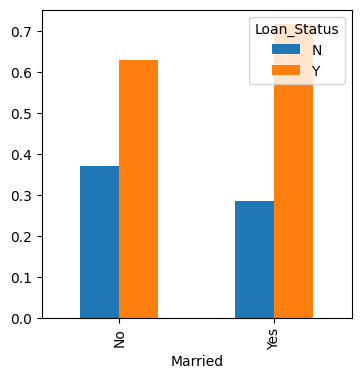

In [95]:
Marital_Status = pd.crosstab(df['Married'], df['Loan_Status'])
Marital_Status.div(Marital_Status.sum(1).astype(float), axis=0).plot(kind="bar", figsize=(4,4))

It can be inferred that the proportion of married applicants who got the loan approval is slightly higher than that of the un-married applicants (70% vs 60%)

## Loan Status Vs. Education

<Axes: xlabel='Education'>

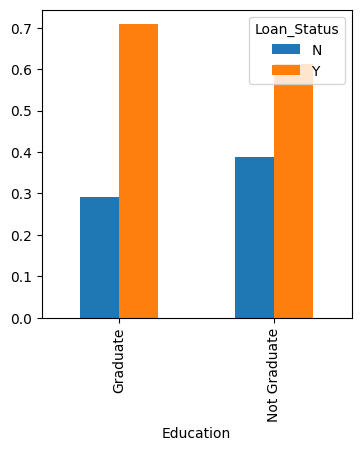

In [96]:
Education = pd.crosstab(df['Education'], df['Loan_Status'])
Education.div(Education.sum(1).astype(float), axis=0).plot(kind="bar", figsize=(4,4))

It can be inferred from the above plot that the proportion of Garduates who got the loan approval is marginally higher than that of the Non-graduates

## Loan Status Vs. Credit History

<Axes: xlabel='Credit_History'>

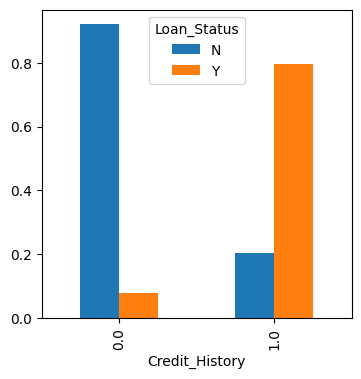

In [97]:
Credit_History = pd.crosstab(df['Credit_History'], df['Loan_Status'])
Credit_History.div(Credit_History.sum(1).astype(float), axis=0).plot(kind="bar", figsize=(4,4))

It can be inferred from the above plot that applicants with a Credit History are most likely to get the loan approval

## Loan Status Vs. Applicant Income

For doing an effective comparison, we shall use the Binning technique to compare the Applicant Income and Loan Status. I.e. We shall categories the Applicant income into multiple buckets or bins and then compare with the Loan Status.

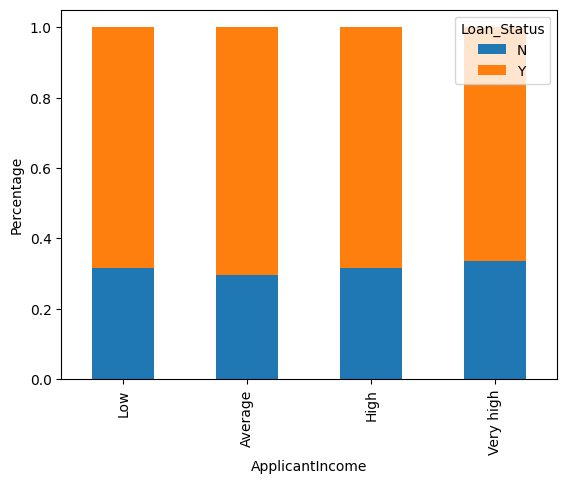

In [98]:
bins = [0, 2500, 4000, 6000, 81000]
group = ['Low','Average','High', 'Very high']
df['Income_bin'] = pd.cut(df['ApplicantIncome'], bins, labels = group)
Income_bin = pd.crosstab(df['Income_bin'], df['Loan_Status'])
Income_bin.div(Income_bin.sum(1).astype(float), axis=0).plot(kind="bar", stacked=True)
plt.xlabel('ApplicantIncome')
P = plt.ylabel('Percentage')

It can be inferred that Applicant’s income does not  significantly affect the chances of loan approval

# Handle the Missing Values

Let's get the feature-wise count of missing values

In [99]:
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


It is observed that the following features have null values: Gender, Married, Dependents, Self-Employed, LoanAmount, Loan_Amount_Term and Credit_History

## Handle the missing values in the Categorical Variables

For the categorical variables (Gender, Married, Dependents, Credit_History, and Self_Employed), we shall replace the missing values with the Mode value of that feature. i.e. the value that appears most for that feature.

In [100]:
# The missing values are replaced with the mode, using the fillna function
df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
df['Married'].fillna(df['Married'].mode()[0], inplace=True)
df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)
df['Self_Employed'].fillna(df['Self_Employed'].mode()[0], inplace=True)
df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace=True)

Next we shall analyse the null values in the Loan Amount Term variable

In [101]:
df['Loan_Amount_Term'].value_counts()

,count
Loan_Amount_Term,
360.0,512
180.0,44
480.0,15
300.0,13
84.0,4
240.0,4
120.0,3
60.0,2
36.0,2


It can be seen that the loan amount term value of 360 is the most used. Therefore we shall replace the missing values in this variable using the mode of this variable i.e. 360

In [102]:
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0], inplace=True)

## Handle the missing values in the Numerical Variables

For the numerical variables (LoanAmount) the missing values are typically replaced with the Mean or Median of that feature. The decision to choose between Mean and Median is based on the ouliers present in the data. If there are outliers, we should go for Median instead of Mean

In order to detect the presence of outliers in our dataset, we shall use the Boxplot that is available in the seaborn library.

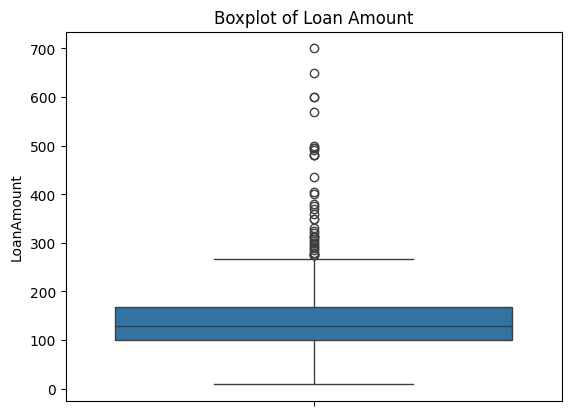

In [103]:
sns.boxplot(df['LoanAmount'])
plt.title('Boxplot of Loan Amount')
plt.show()

All of the datapoints that appear outside the Whisker lines are considered as outliers. In the LoanAmount data, we can see that there are many datapoints that are higher than 300 and hence considered as outliers.

Since we have many outliers in the data, we shall use the Median value of the LoanAmount to replace the null values in the variable.

In [104]:
df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)

In [105]:
#Checking the null value count again to ensure there are no more missing values
df.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


Now that we have handled all of the Null data, we dont have any missing values in the dataset.

# Build the Model

The given business problem is to predict the Target Variable i.e. LoanStatus, based on the given set of Independent Variables. The LoanStatus being a Binary Variable (Yes / No), we shall go with a **Logistic Regression Model**, which is a Classification algorithm.

## Feature Engineering

### Remove the Unwanted Variables

The Loan ID is a system generated variable and does not have any effect on the Target Variable. Hence we shall drop the Loan ID variable

In [106]:
df = df.drop('Loan_ID', axis = 1)

We would be using the *scikit-learn* (sklearn) library for building the Logistic Regression model

Sklearn requires the Target variable and Independent Variables in separate datasets. So, we shall drop our Target variable from the training dataset and save it in another dataset.

In [107]:
df_tv = df['Loan_Status'] # Dataframe for the Target Variable
df_iv = df.drop('Loan_Status', axis = 1) # Dataframe for the Independent Variables
df_tv.shape, df_iv.shape

((614,), (614, 12))

### Convert the Categorical Variables to Numeric

The Categorical Variables like Gender, Married, Education shall be converted into Numerical Variables using **One-Hot Encoding** technique. This is done, since the Logistic Regression Model takes only Numerical variables as input

In [108]:
# One-Hot Encoding is done using get_dummies method in the Pandas library
df = pd.get_dummies(df)
df_iv = pd.get_dummies(df_iv)
df_iv.head()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Gender_Female,Gender_Male,Married_No,Married_Yes,Dependents_0,...,Education_Not Graduate,Self_Employed_No,Self_Employed_Yes,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban,Income_bin_Low,Income_bin_Average,Income_bin_High,Income_bin_Very high
0,5849,0.0,128.0,360.0,1.0,False,True,True,False,True,...,False,True,False,False,False,True,False,False,True,False
1,4583,1508.0,128.0,360.0,1.0,False,True,False,True,False,...,False,True,False,True,False,False,False,False,True,False
2,3000,0.0,66.0,360.0,1.0,False,True,False,True,True,...,False,False,True,False,False,True,False,True,False,False
3,2583,2358.0,120.0,360.0,1.0,False,True,False,True,True,...,True,True,False,False,False,True,False,True,False,False
4,6000,0.0,141.0,360.0,1.0,False,True,True,False,True,...,False,True,False,False,False,True,False,False,True,False


In [109]:
df_iv.shape

(614, 24)

You can see that all the Categorical variables have been replaced with corresponding columns that contain Boolean Values.

## Analyse the correlation between features

This can be done by analysing the correlation between the variables. A correlation matrix is plotted. The correlation between two variables is a measure of how the variables are related. It can be positive, negative or zero. A positive correlation means that as one variable increases, the other variable also increases. A negative correlation means that as one variable increases, the other variable decreases. A zero correlation means that there is no relationship between the variables.

In [110]:
corr = df.corr()
corr.style.background_gradient(cmap='coolwarm')

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Gender_Female,Gender_Male,Married_No,Married_Yes,Dependents_0,Dependents_1,Dependents_2,Dependents_3+,Education_Graduate,Education_Not Graduate,Self_Employed_No,Self_Employed_Yes,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban,Loan_Status_N,Loan_Status_Y,Income_bin_Low,Income_bin_Average,Income_bin_High,Income_bin_Very high
ApplicantIncome,1.000000,-0.116605,0.565181,-0.046531,-0.018615,-0.058809,0.058809,-0.051708,0.051708,-0.092599,0.040861,-0.034650,0.156687,0.140760,-0.140760,-0.127180,0.127180,0.015829,-0.014246,-0.000598,0.004710,-0.004710,-0.255422,-0.268047,-0.044086,0.588832
CoapplicantIncome,-0.116605,1.000000,0.189218,-0.059383,0.011134,-0.082912,0.082912,-0.075948,0.075948,-0.008292,-0.029769,0.010016,0.041491,0.062290,-0.062290,0.016100,-0.016100,0.005329,-0.027044,0.022776,0.059187,-0.059187,0.206859,-0.015425,-0.063499,-0.106832
LoanAmount,0.565181,0.189218,1.000000,0.036960,-0.000607,-0.106904,0.106904,-0.146546,0.146546,-0.147639,0.061976,0.020126,0.152850,0.168759,-0.168759,-0.115100,0.115100,0.043467,-0.005804,-0.036050,0.033214,-0.033214,-0.206828,-0.250347,-0.014791,0.494150
Loan_Amount_Term,-0.046531,-0.059383,0.036960,1.000000,-0.004705,0.074030,-0.074030,0.100912,-0.100912,0.118163,-0.088492,-0.010609,-0.077273,0.073928,-0.073928,0.033739,-0.033739,0.034321,0.059141,-0.094279,0.022549,-0.022549,0.078388,-0.071591,0.046406,-0.035865
Credit_History,-0.018615,0.011134,-0.000607,-0.004705,1.000000,-0.009170,0.009170,-0.010938,0.010938,0.020500,0.009757,0.007987,-0.060473,0.073658,-0.073658,0.001550,-0.001550,-0.020906,0.035976,-0.016934,-0.540556,0.540556,-0.004195,-0.021497,0.018913,0.009537
Gender_Female,-0.058809,-0.082912,-0.106904,0.074030,-0.009170,1.000000,-1.000000,0.364569,-0.364569,0.148421,0.004466,-0.129953,-0.096319,0.045364,-0.045364,-0.000525,0.000525,-0.080283,0.108623,-0.034530,0.017987,-0.017987,0.047627,0.015524,0.009133,-0.070808
Gender_Male,0.058809,0.082912,0.106904,-0.074030,0.009170,-1.000000,1.000000,-0.364569,0.364569,-0.148421,-0.004466,0.129953,0.096319,-0.045364,0.045364,0.000525,-0.000525,0.080283,-0.108623,0.034530,-0.017987,0.017987,-0.047627,-0.015524,-0.009133,0.070808
Married_No,-0.051708,-0.075948,-0.146546,0.100912,-0.010938,0.364569,-0.364569,1.000000,-1.000000,0.348175,-0.113853,-0.249547,-0.132566,0.012304,-0.012304,0.004489,-0.004489,0.006805,-0.005845,-0.000546,0.091478,-0.091478,-0.031147,0.053915,-0.004918,-0.028979
Married_Yes,0.051708,0.075948,0.146546,-0.100912,0.010938,-0.364569,0.364569,-1.000000,1.000000,-0.348175,0.113853,0.249547,0.132566,-0.012304,0.012304,-0.004489,0.004489,-0.006805,0.005845,0.000546,-0.091478,0.091478,0.031147,-0.053915,0.004918,0.028979
Dependents_0,-0.092599,-0.008292,-0.147639,0.118163,0.020500,0.148421,-0.148421,0.348175,-0.348175,1.000000,-0.531373,-0.528246,-0.358315,0.036563,-0.036563,0.088254,-0.088254,0.044015,-0.004173,-0.038264,0.003044,-0.003044,0.118801,0.030800,-0.053544,-0.089960


From the above two correlation matrix, we can see that Credit History has a positive correlation of 0.540556 with the target value Loan_Status. Based on this, we can say that Loan_Status is most dependent on Credit_History.

## Split the dataset into Training and Validation

We shall split the dataset into Training and Validation with a 70-30 proportion. The training dataset would be used to train the model. Both the Target dataset and the IV dataset would be split.

In [111]:
from sklearn.model_selection import train_test_split
# df_iv would be split into df_iv_train and df_iv_val
# df_tv would be split into df_tv_train and df_tv_val
df_iv_train, df_iv_val, df_tv_train, df_tv_val = train_test_split(df_iv, df_tv, test_size =0.3)
df_iv_train.shape, df_iv_val.shape, df_tv_train.shape, df_tv_val.shape

((429, 24), (185, 24), (429,), (185,))

Both the TV and IV datasets have been split into Training and Validation parts

## Fit the Regression Model

Import LogisticRegression and accuracy_score from sklearn and fit the Logistic Regression model.

In [112]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model = LogisticRegression()
model.fit(df_iv_train, df_tv_train)

LogisticRegression()

The Logistic Regression Model has been fitted

## Evaluate the Model

The Model would be evaluated by predicting the Loan Status for the Validation dataset and then calculating the accuracy of the prediction

In [113]:
# Predict the Loan Status for the Validation dataset and store the prediction in a separate dataset
df_tv_pred = model.predict(df_iv_val)
df_tv_pred.shape

(185,)

In [114]:
# Calculate the accuracy of the prediction by comparing the TV validation and prediction datasets
accuracy_score(df_tv_val, df_tv_pred)

0.7567567567567568

Our prediction is **75%** accurate. i.e. 75% of the Loan Status in the validation dataset have been predicted correctly.

# Identify the Top 5 most influential features

We shall use the Random Forest method to identify the top 5 most influencial features that would impact the Loan Status. Random Forest is an algorithm based on decision trees.
For this, We shall use the RandomForestRegressor library from sklearn.

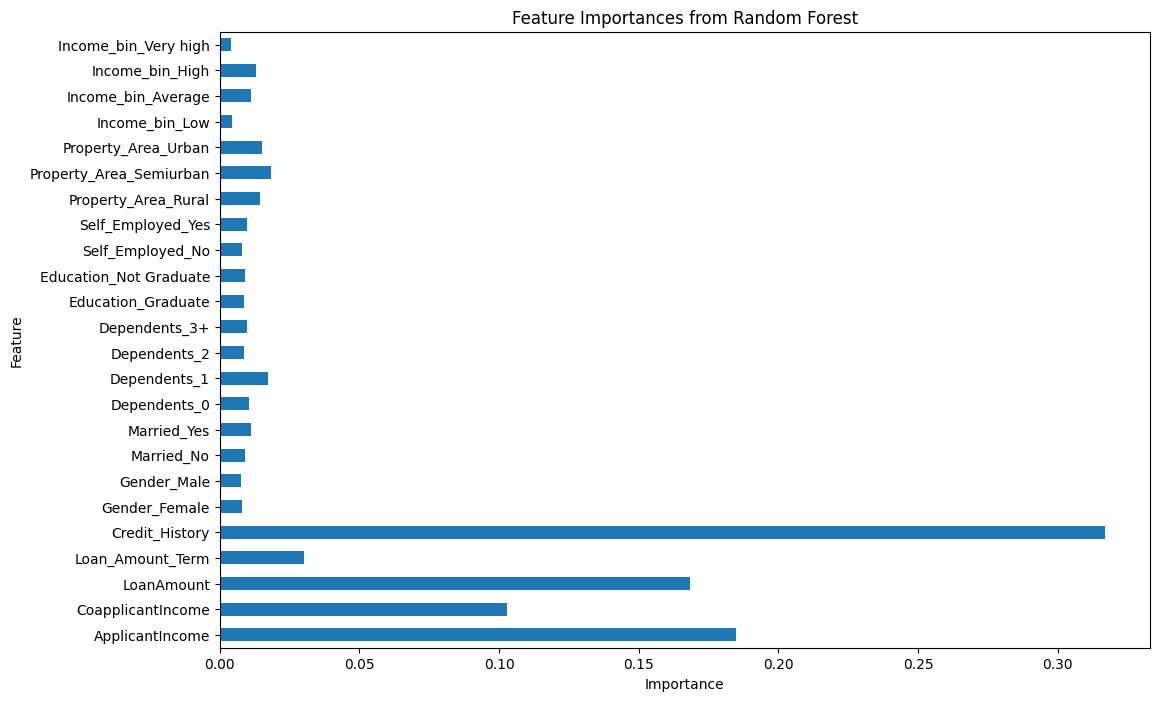

Feature Importances:
ApplicantIncome      0.185
CoapplicantIncome    0.103
LoanAmount           0.168
Loan_Amount_Term     0.030
Credit_History       0.317
Gender_Female        0.008
Gender_Male          0.007
Married_No           0.009
Married_Yes          0.011
Dependents_0         0.010
Dependents_1         0.017
Dependents_2         0.009
Dependents_3+        0.010
Education_Graduate   0.009
Education_Not Graduate 0.009
Self_Employed_No     0.008
Self_Employed_Yes    0.010
Property_Area_Rural  0.014
Property_Area_Semiurban 0.018
Property_Area_Urban  0.015
Income_bin_Low       0.004
Income_bin_Average   0.011
Income_bin_High      0.013
Income_bin_Very high 0.004


In [115]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

forest = RandomForestRegressor(random_state=0)
XTrain = df_iv_train
yTrain = df_tv_train
yTrain = yTrain.replace({'Y': 1, 'N': 0})
forest.fit(XTrain, yTrain)

# Fetch the importances
importances = forest.feature_importances_

# Convert importances to a pandas Series with feature names as index
feature_importances = pd.Series(importances, index=XTrain.columns)

# Plot the importances
feature_importances.plot(kind='barh', figsize=(12,8))
plt.title('Feature Importances from Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

# Print feature names and their importances
print("Feature Importances:")
for i in range(len(importances)):
  print(f"{XTrain.columns[i]:<20} {importances[i]:.3f}")

From the above plot, we can see that Credit History, Applicant Income, Loan Amount, Co-applicant Income and the Loan Term are the top 5 variables that influence the Loan approval status.

# Fine Tune the Model

We will fine tune the Logistic regression model by removing the low influence features

In [116]:
df_iv_train2 = df_iv_train.drop(['Income_bin_Low', 'Income_bin_Very high', 'Gender_Female', 'Self_Employed_Yes', 'Self_Employed_No', 'Dependents_3+', 'Gender_Male'], axis = 1)
df_iv_val2 = df_iv_val.drop(['Income_bin_Low', 'Income_bin_Very high', 'Gender_Female', 'Self_Employed_Yes', 'Self_Employed_No', 'Dependents_3+', 'Gender_Male'], axis = 1)

model2 = LogisticRegression()
model2.fit(df_iv_train2, df_tv_train)

df_tv_pred2 = model2.predict(df_iv_val2)

accuracy_score(df_tv_val, df_tv_pred2)

0.7621621621621621

We can observe that by fine tuning the model, there is a slight increase in the accuracy - **76%**.

# Conclusion

The problem statement in this case study was to predict the Loan Approval Status based on the dataset provided.

We started by importing the dataset into the colab runtime and analysed the basic statistics of the dataset.

Then we did an Exploratory Data Analysis (EDA) of the dataset, by comparing the various features of the dataset, using visualization techniques. The observations are as follows:



*   69% of people out of 614 got approval for their loan application
*   80% of applicants in the dataset are male.
Around 65% of the applicants in the dataset are married
*   About 15% of applicants in the dataset are self-employed
*   About 85% of applicants have repaid their debts
*   80% of applicants in the dataset are male
*   Around 65% of the applicants in the dataset are married
*   Around 78% of applicants in the dataset are Graduates
*   About 85% of applicants have repaid their debts
*   Most of the applicants don’t have dependents
*   Most of the applicants are from semi-urban areas



*   The proportion loan approvals is more or less same for Female as well as Male applicants
*   The proportion of married applicants who got the loan approval is slightly higher than that of the un-married applicants (70% vs 60%)
*   The proportion of Garduates who got the loan approval is marginally higher than that of the Non-graduates (70% vs 60%)
*   Applicants with a Credit History are most likely to get the loan approval

We then handled the missing values in the dataset using the following methods:

*   For the categorical variables (Gender, Married, Dependents, Credit_History, and Self_Employed), we replaced the missing values with the Mode value of that feature. i.e. the value that appears most for that feature.
*   For the numerical variables (LoanAmount) the missing values were replaced with the Median of that feature.



We then started building the Logistic Regression model using the following steps:

1.   Feature Engineering: Remove unwanted variables, convert categorical variables to numeric using One-Hot encoding
2.   Analyze the correlation between the features in the dataset
3.   Split the dataset into Training and Validation
4.   Fit the regression model
5.   Predict the Target variable for the Validation dataset and Evaluate the accuracy of the prediction



We then identified the top 5 most influencial features in the dataset. These were as follows in the decreasing order:

1.   Credit History
2.   Applicant Income
3.   Loan Amount
4.   Co-applicant Income
5.   Loan Amount Term



Finally we fine tuned the model by removing some of the low-impact features and observed an increase the model accuracy